In [1]:
# import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix

In [2]:
# Data import
import sys
sys.path.append("..")
from data_loader import get_data
from cross_val_data import cross_validation

X_tr, X_val, X_te, y_tr, y_val, y_te = get_data()

In [4]:
print(f"X_tr: {X_tr.shape}, X_val: {X_val.shape}, X_te: {X_te.shape}")
print(f"y_tr: {y_tr.shape}, y_val: {y_val.shape}, y_te: {y_te.shape}")

X_tr: (48000, 784), X_val: (12000, 784), X_te: (10000, 784)
y_tr: (48000,), y_val: (12000,), y_te: (10000,)


In [5]:
print(np.unique(y_tr))

[0 1 2 3 4 5 6 7 8 9]


In [6]:
# Data reshape and setup
X_tr_cnn = X_tr.reshape(-1,28,28,1)
X_val_cnn = X_val.reshape(-1,28,28,1)
X_te_cnn = X_te.reshape(-1,28,28,1)

print("Reshaped data:")
print(f"X_tr: {X_tr_cnn.shape}")
print(f"X_val: {X_val_cnn.shape}")
print(f"X_te: {X_te_cnn.shape}")

Reshaped data:
X_tr: (48000, 28, 28, 1)
X_val: (12000, 28, 28, 1)
X_te: (10000, 28, 28, 1)


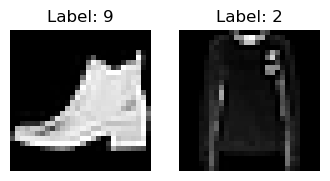

In [7]:
# Random shows data as image
fig, ax = plt.subplots(1,2,figsize=[4,4])
ax[0].imshow(X_tr_cnn[1325,:,:,0],cmap="gray")
ax[0].set_title(f'Label: {y_tr[1325]}')
ax[0].set_axis_off()

ax[1].imshow(X_tr_cnn[5678,:,:,0], cmap="gray")
ax[1].set_title(f'Label: {y_tr[5678]}')
ax[1].set_axis_off()

plt.show()

#### Train CNN

In [8]:
tr_fold, val_fold = cross_validation()

In [ ]:
def model_1_layer(X_tr, y_tr, X_val, y_val):
    model = models.Sequential([
        # First Convolution
        # 64 filters with 2x2, activation with relu
        layers.Conv2D(64, kernel_size=(2,2), activation="relu", input_shape=(28,28,1)),
        # Pooling
        layers.MaxPool2D(pool_size=(2,2)),

        # Flatten
        layers.Flatten(),
        
        # Fully connected FNN
        layers.Dense(128, activation="relu"),
        # Output of P(y=k|x), k=0,1,...,9
        layers.Dense(10, activation="softmax")]
    )

    model.compile(optimizer="adam",
                loss="crossentropy",
                metrics=["accuracy"])

    history = model.fit(X_tr, y_tr, epochs=10,batch_size=64, validation_data=[X_val, y_val])

    return model, history

In [33]:
def model_3_layer(X_tr, y_tr, X_val, y_val):
    model = models.Sequential([
        # First Convolution
        # 53 filters with 2x2, activation with relu
        layers.Conv2D(64, kernel_size=(2,2), activation="relu", padding="same",input_shape=(28,28,1)),
        # Pooling
        layers.MaxPool2D(pool_size=(2,2)),

        layers.Conv2D(64, kernel_size=(2,2), activation="relu", padding="same"),
        # Pooling
        layers.MaxPool2D(pool_size=(2,2)),

        layers.Conv2D(64, kernel_size=(2,2), activation="relu", padding="same"),
        # Pooling
        layers.MaxPool2D(pool_size=(2,2)),

        # Flatten
        layers.Flatten(),
        
        # Fully connected FNN
        layers.Dense(128, activation="relu"),
        # Output of P(y=k|x), k=0,1,...,9
        layers.Dense(10, activation="softmax")]
    )

    model.compile(optimizer="adam",
                loss="crossentropy",
                metrics=["accuracy"])

    history = model.fit(X_tr, y_tr, epochs=10,batch_size=64, validation_data=[X_val, y_val])

    return model, history

In [40]:
def model_4_layer(X_tr, y_tr, X_val, y_val):
    model = models.Sequential([
        # First Convolution
        # 64 filters with 2x2, activation with relu
        layers.Conv2D(64, kernel_size=(2,2), activation="relu", padding="same", input_shape=(28,28,1)),
        # Pooling
        layers.MaxPool2D(pool_size=(2,2)),

        layers.Conv2D(64, kernel_size=(2,2), activation="relu", padding="same"),
        # Pooling
        layers.MaxPool2D(pool_size=(2,2)),

        layers.Conv2D(64, kernel_size=(2,2), activation="relu", padding="same"),
        # Pooling
        layers.MaxPool2D(pool_size=(2,2)),

        layers.Conv2D(64, kernel_size=(2,2), activation="relu", padding="same"),
        # Pooling
        layers.MaxPool2D(pool_size=(2,2)),

        # Flatten
        layers.Flatten(),
        
        # Fully connected FNN
        layers.Dense(128, activation="relu"),
        # Output of P(y=k|x), k=0,1,...,9
        layers.Dense(10, activation="softmax")]
    )

    model.compile(optimizer="adam",
                loss="crossentropy",
                metrics=["accuracy"])

    history = model.fit(X_tr, y_tr, epochs=10,batch_size=64, validation_data=[X_val, y_val])

    return model, history

In [17]:
def visualize_plot(history):
    fig, ax = plt.subplots(1,2,figsize=(12,5))
    ax[0].plot(history.history["loss"], label="Training Loss")
    ax[0].plot(history.history["val_loss"],label="Val Loss")
    ax[0].set_xlabel("epoch")
    ax[0].set_ylabel("Loss")
    ax[0].legend()

    ax[1].plot(history.history["accuracy"], label="Training Accuracy")
    ax[1].plot(history.history["val_accuracy"], label="Val Accuracy")
    ax[1].set_xlabel("epoch")
    ax[1].set_ylabel("Accuracy")
    ax[1].legend()

    plt.show()

In [26]:
def cross_val_train_pipline(model, tr_fold, val_fold):
    model_dict = {}
    for k in range(len(tr_fold)):
        fitted_model, history = model(tr_fold[k][0], tr_fold[k][1], val_fold[k][0], val_fold[k][1])
        model_dict[f"model{k+1}"] = history
    
    return model_dict

In [27]:
dict_layer_1 = cross_val_train_pipline(model_1_layer, tr_fold, val_fold)

/opt/anaconda3/envs/cs178/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8407 - loss: 0.4518 - val_accuracy: 0.8800 - val_loss: 0.3471
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8894 - loss: 0.3046 - val_accuracy: 0.8838 - val_loss: 0.3242
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9066 - loss: 0.2578 - val_accuracy: 0.9020 - val_loss: 0.2764
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9179 - loss: 0.2237 - val_accuracy: 0.9058 - val_loss: 0.2724
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9266 - loss: 0.1979 - val_accuracy: 0.8989 - val_loss: 0.2869
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9363 - loss: 0.1751 - val_accuracy: 0.9083 - val_loss: 0.2679
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9435 - loss: 0.1553 - val_accuracy: 0.9118 - val_loss: 0.2559
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9504 - loss: 0.1346 - 

In [28]:
dict_layer_1

{'model1': <keras.src.callbacks.history.History at 0x30b7c44c0>,
 'model2': <keras.src.callbacks.history.History at 0x31f1153c0>,
 'model3': <keras.src.callbacks.history.History at 0x31eab84c0>,
 'model4': <keras.src.callbacks.history.History at 0x31f5c8130>,
 'model5': <keras.src.callbacks.history.History at 0x320f304c0>}

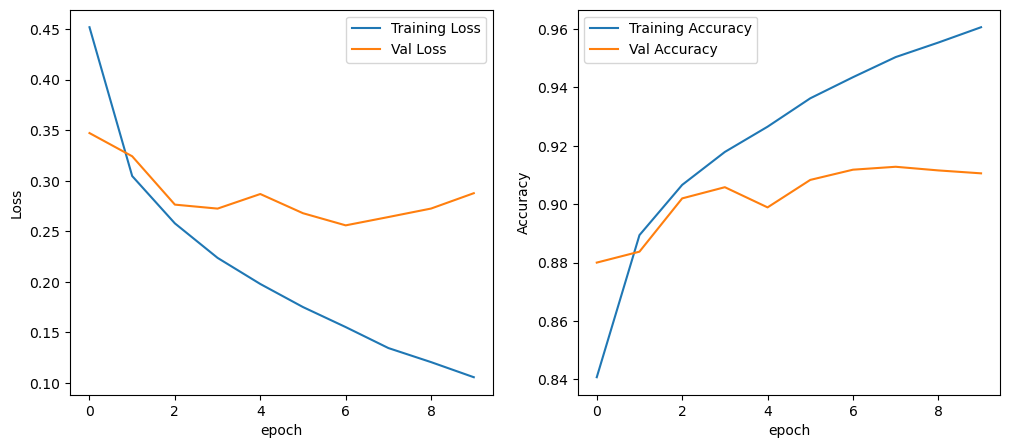

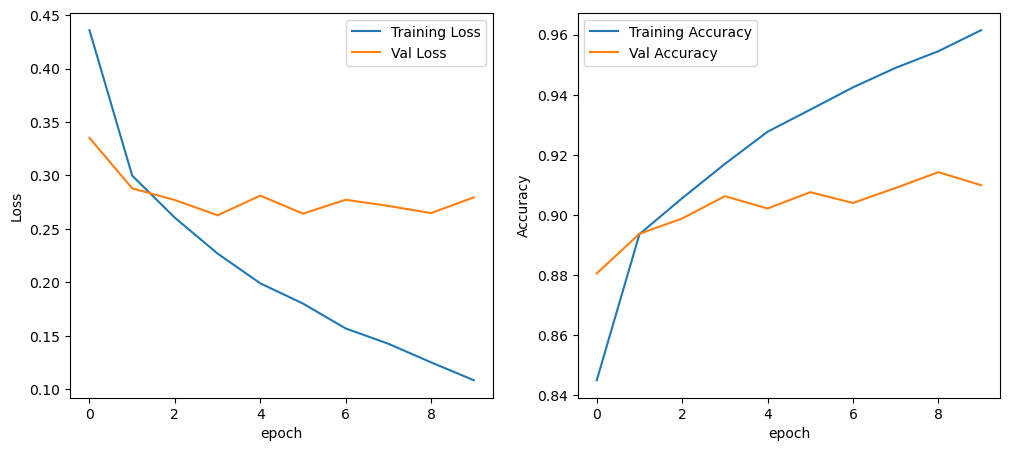

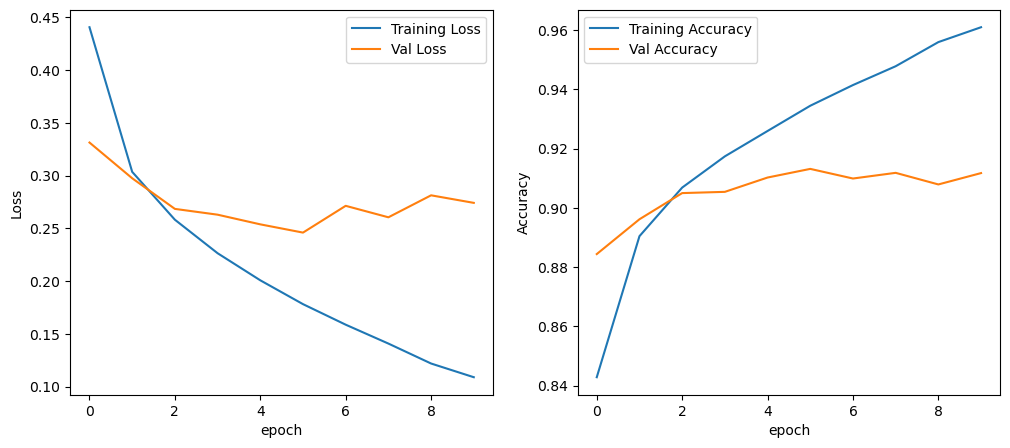

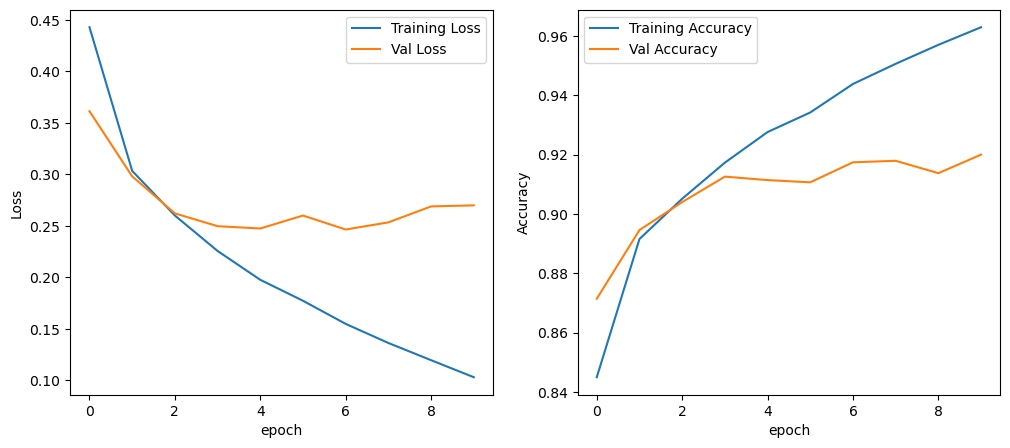

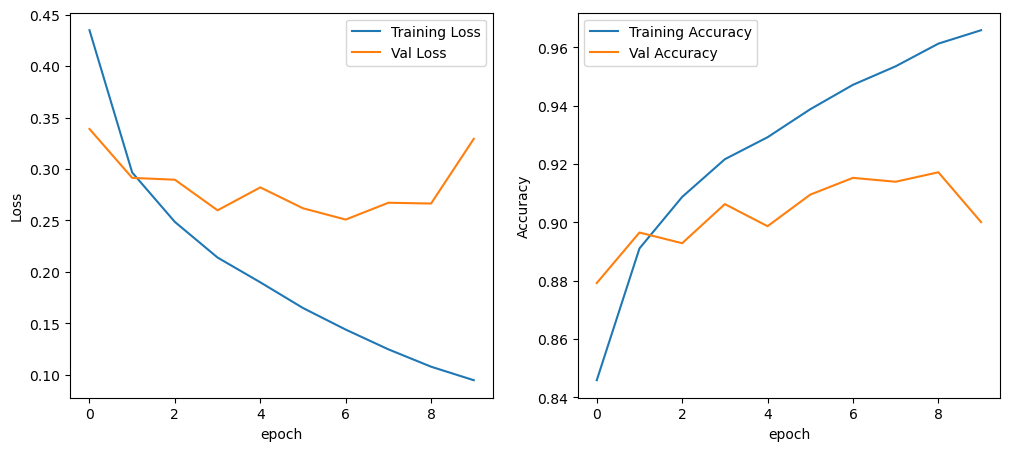

In [29]:
for key, value in dict_layer_1.items():
    visualize_plot(value)

In [43]:
def calculate_average_loss_acc(model_dict):
    max_loss = []
    max_acc = []

    for key, value in model_dict.items():
        max_loss.append(min(value.history['val_loss']))
        max_acc.append(max(value.history["val_accuracy"]))

    average_loss = np.sum(max_loss) / 5
    average_acc = np.sum(max_acc) / 5

    return average_loss, average_acc

In [44]:
calculate_average_loss_acc(dict_layer_1)

(np.float64(0.2523564130067825), np.float64(0.9154833316802978))

In [34]:
dict_layer_3 = cross_val_train_pipline(model_3_layer, tr_fold, val_fold)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.8045 - loss: 0.5460 - val_accuracy: 0.8719 - val_loss: 0.3594
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8772 - loss: 0.3383 - val_accuracy: 0.8864 - val_loss: 0.3233
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8936 - loss: 0.2927 - val_accuracy: 0.8960 - val_loss: 0.2877
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.9004 - loss: 0.2657 - val_accuracy: 0.9008 - val_loss: 0.2712
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9092 - loss: 0.2443 - val_accuracy: 0.9072 - val_loss: 0.2531
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.9155 - loss: 0.2262 - val_accuracy: 0.9102 - val_loss: 0.2487
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9212 - loss: 0.2072 - val_accuracy: 0.8943 - val_loss: 0.2918
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9281 - loss: 0.1926 - 

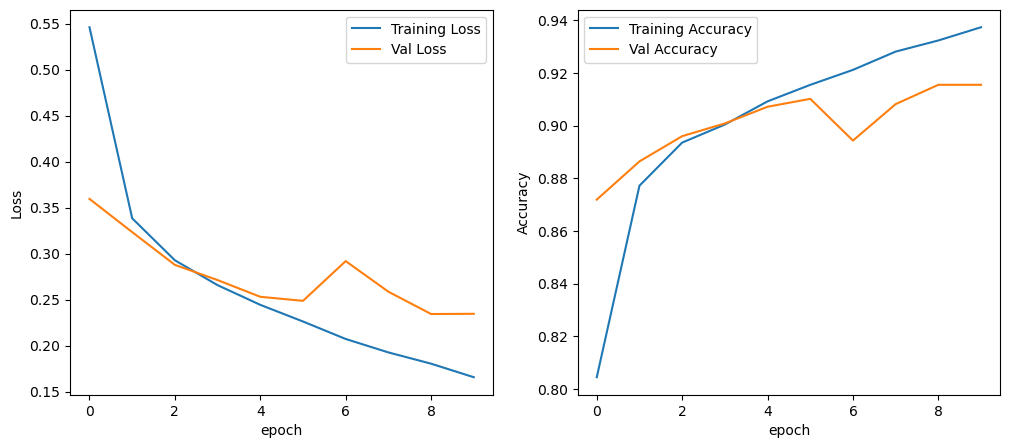

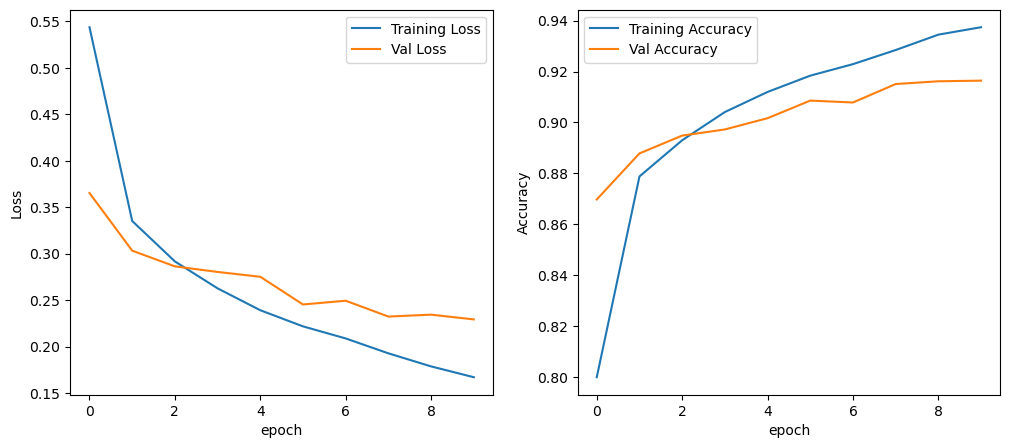

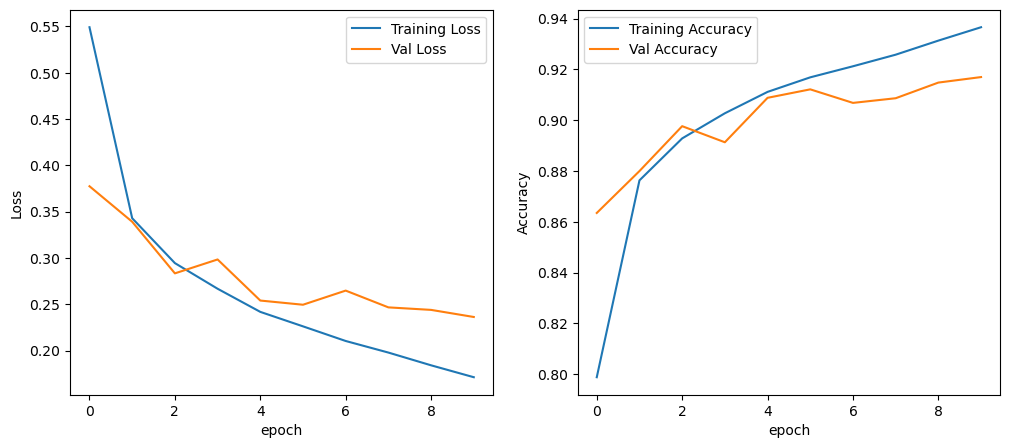

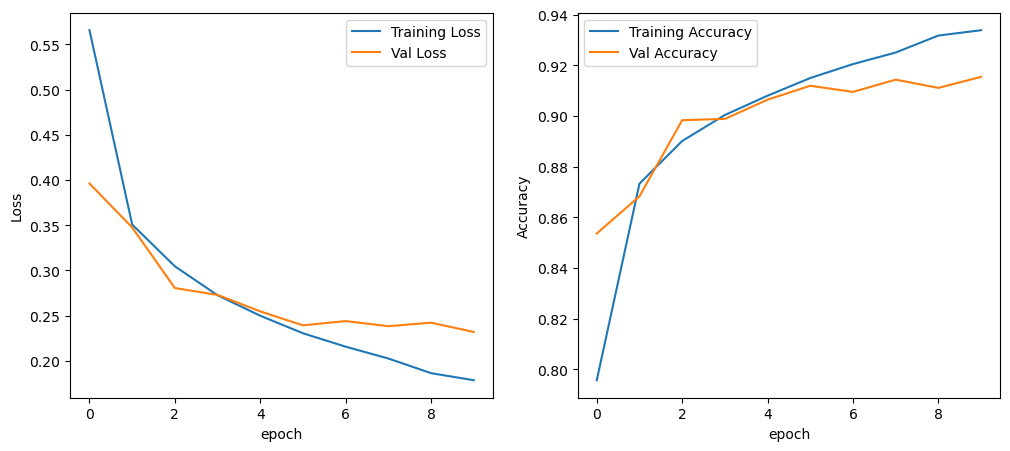

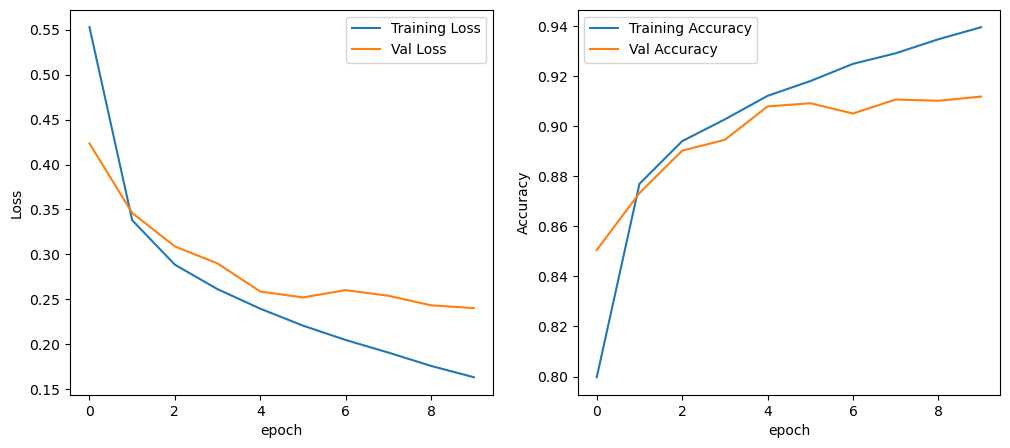

In [35]:
for key, value in dict_layer_3.items():
    visualize_plot(value)

In [45]:
calculate_average_loss_acc(dict_layer_3)

(np.float64(0.23439890146255493), np.float64(0.9152166604995727))

In [41]:
dict_layer_4 = cross_val_train_pipline(model_4_layer,tr_fold, val_fold)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.7605 - loss: 0.6468 - val_accuracy: 0.8452 - val_loss: 0.4329
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.8608 - loss: 0.3813 - val_accuracy: 0.8751 - val_loss: 0.3427
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.8793 - loss: 0.3299 - val_accuracy: 0.8849 - val_loss: 0.3202
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.8909 - loss: 0.2962 - val_accuracy: 0.8864 - val_loss: 0.3130
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.8981 - loss: 0.2747 - val_accuracy: 0.8935 - val_loss: 0.2899
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.9057 - loss: 0.2566 - val_accuracy: 0.8928 - val_loss: 0.2951
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.9109 - loss: 0.2395 - val_accuracy: 0.9007 - val_loss: 0.2803
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.9160 - loss: 0.2252 - 

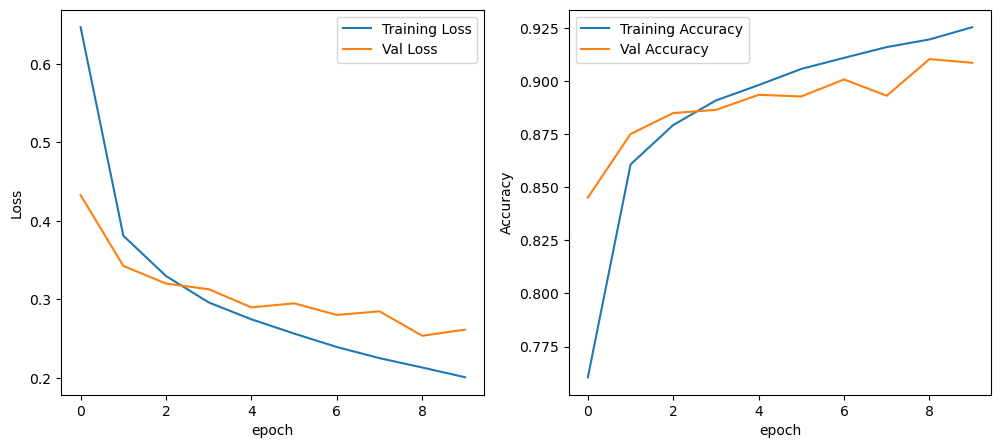

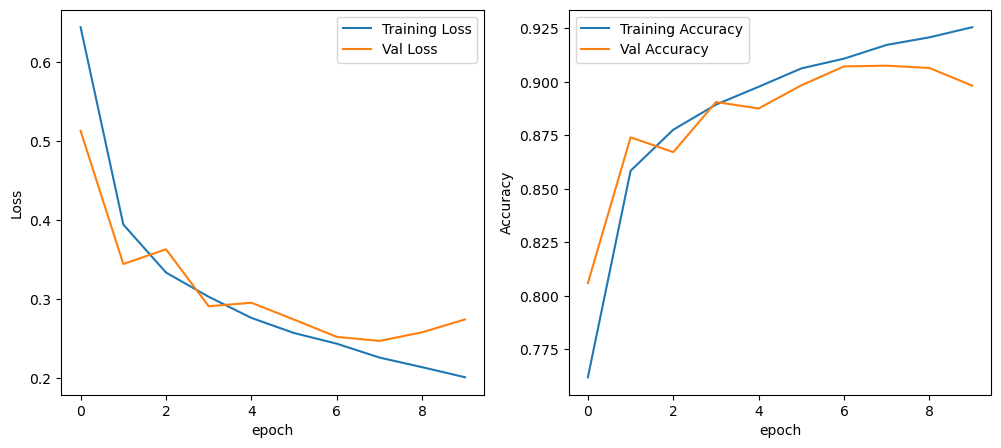

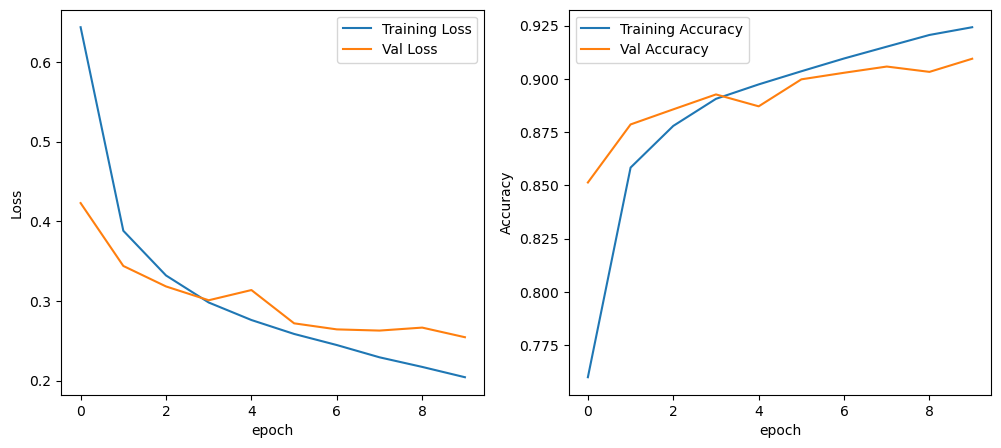

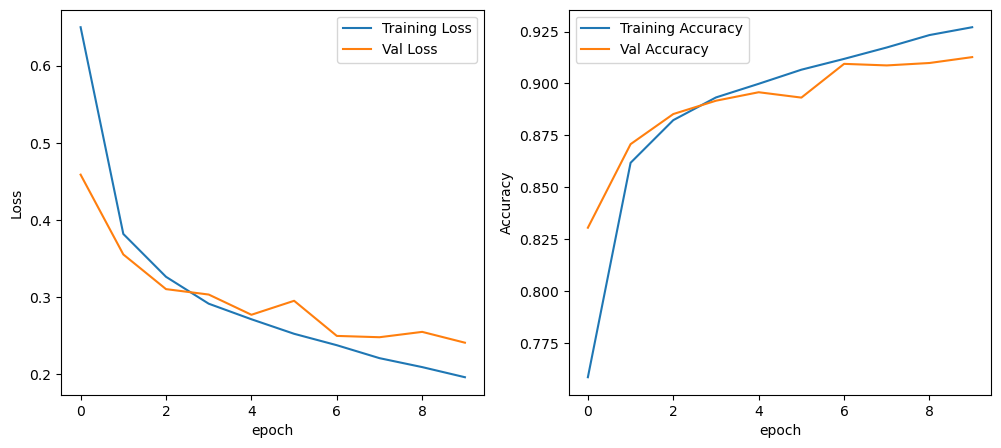

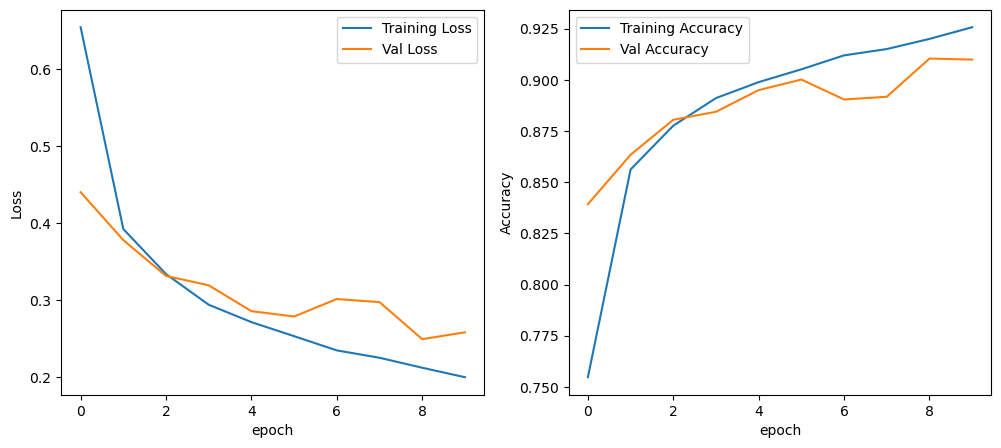

In [42]:
for key, value in dict_layer_4.items():
    visualize_plot(value)

In [46]:
calculate_average_loss_acc(dict_layer_4)

(np.float64(0.24910691976547242), np.float64(0.9100833415985108))